#### 2026-01-29\_accuracy\_metrics\_2022.ipynb
**Author**: Jay Sayre
**Date Modified**: 2026-02-27
**Description**: Computes accuracy metrics (standard R², within-R², between-R², RMSE) comparing maize yield predictions from RS-based and AEF-based models against INEGI 2022 agricultural census data and SIAP municipal estimates. Includes GP-corrected predictions (produced by `2026-01-30_gp_correction_2022.ipynb`). Metrics are decomposed into between-municipality and within-municipality components. Results are formatted for academic publication.

**Inputs**:
- `adc_yield_preds_corrected_2022.csv` — RS-based yield predictions (raw + ex-post corrected)
- `adc_alpha_earth_preds.csv` — AEF standard yield predictions
- `adc_mlp_yield_preds.csv` — AEF MLP yield predictions (aggregation-constrained)
- `adc_gp_yield_preds_2022.csv` — GP-corrected yield predictions (from gp\_correction notebook)
- `mun_hist_raw_rf_preds.parquet` — Histogram RF yield predictions at mun level (LOYO CV)
- `adc_land_use_ca22_adc07.dta` — INEGI 2022 census data at 2007 ADC boundaries (combined)
- `adc_land_szn_ca22_adc07.dta` — INEGI 2022 census data by growing season
- `siap_ag_prod_estimation_ca2007.dta` — SIAP municipality-level production estimates

**Outputs**: Summary tables and scatter plots of accuracy metrics

In [1]:
import pandas as pd
import os
import numpy  as np
from   scipy  import stats
import matplotlib.pyplot as plt

base_font_size = 12

### Directories
dropbox_dir   =  os.path.join(os.path.expanduser("~"), "Dropbox", "Projects")
poppy_dir     =  os.path.join(dropbox_dir,  "Maize_prediction")
crop_sub_dir  =  os.path.join(dropbox_dir,  "Maize_prediction")
siap_dir      =  os.path.join(crop_sub_dir, "Data", "SIAP", "Cleaned")
joel_dir      =  os.path.join(poppy_dir,    "Data", "predictions")
py_md_lab_dir =  os.path.join(poppy_dir,    "Data", "INEGI", "MD_lab_outputs")
ca2022_adc_d  =  os.path.join(py_md_lab_dir,"LM2304-CA22-2025-09-29-superficie_ENTREGA")
plot_dir      =  os.path.join(poppy_dir,    "plots")

### Inputs — INEGI ground truth (2022 census at 2007 ADC boundaries)
adc_22_07_path     =  os.path.join(ca2022_adc_d, "adc_land_use_ca22_adc07.dta")   # combined season
adc_22_07_szn_path =  os.path.join(ca2022_adc_d, "adc_land_szn_ca22_adc07.dta")   # by growing season

### Inputs — Prediction files
rs_preds_file      =  os.path.join(joel_dir, "adc_yield_preds_corrected_2022.csv") # RS-based (raw + corrected)
aef_preds_file     =  os.path.join(joel_dir, "adc_alpha_earth_preds.csv")          # AEF standard
mlp_preds_file     =  os.path.join(joel_dir, "adc_mlp_yield_preds.csv")            # AEF MLP (constrained)
gp_preds_file      =  os.path.join(joel_dir, "adc_gp_yield_preds_2022.csv")        # GP-corrected (from gp_correction notebook)

### Inputs — SIAP municipal production estimates
siap_path          =  os.path.join(siap_dir, "siap_ag_prod_estimation_ca2007.dta") # municipal yields

In [2]:
### ------------------------------------------------------------------ ###
### Accuracy metric functions
### ------------------------------------------------------------------ ###

def standard_r2(y_actual, y_predicted):
    """Standard R-squared: 1 - SS_res / SS_tot (penalizes bias)."""
    mask   =  np.isfinite(y_actual) & np.isfinite(y_predicted)
    y      =  np.array(y_actual[mask])
    yhat   =  np.array(y_predicted[mask])
    if len(y) < 2:
        return np.nan
    ss_res =  np.sum((y - yhat) ** 2)
    ss_tot =  np.sum((y - np.mean(y)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1.0 - ss_res / ss_tot


def compute_rmse(y_actual, y_predicted):
    """Root Mean Squared Error."""
    mask =  np.isfinite(y_actual) & np.isfinite(y_predicted)
    y    =  np.array(y_actual[mask])
    yhat =  np.array(y_predicted[mask])
    if len(y) == 0:
        return np.nan
    return np.sqrt(np.mean((y - yhat) ** 2))


def between_r2(df, y_col, yhat_col, group_col='muncode'):
    """Between-group R-squared: R-squared computed on group means."""
    sub =  df[[y_col, yhat_col, group_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(sub) == 0:
        return np.nan
    grp =  sub.groupby(group_col)[[y_col, yhat_col]].mean()
    return standard_r2(grp[y_col], grp[yhat_col])


def within_r2(df, y_col, yhat_col, group_col='muncode'):
    """Within-group R-squared: R-squared on deviations from group means.
    Only uses groups with >= 2 observations."""
    sub =  df[[y_col, yhat_col, group_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    if len(sub) == 0:
        return np.nan
    ### Keep only groups with >= 2 observations
    grp_counts =  sub.groupby(group_col).size()
    valid_grps =  grp_counts[grp_counts >= 2].index
    sub        =  sub[sub[group_col].isin(valid_grps)]
    if len(sub) == 0:
        return np.nan
    grp_means     =  sub.groupby(group_col)[[y_col, yhat_col]].transform('mean')
    y_within      =  sub[y_col]    - grp_means[y_col]
    yhat_within   =  sub[yhat_col] - grp_means[yhat_col]
    return standard_r2(y_within, yhat_within)


def n_paired(y_actual, y_predicted):
    """Number of non-missing paired observations."""
    mask =  np.isfinite(y_actual) & np.isfinite(y_predicted)
    return int(mask.sum())


def compute_all_metrics(df, y_col, yhat_col, group_col='muncode'):
    """Compute all accuracy metrics for a given prediction column."""
    sub =  df[[y_col, yhat_col, group_col]].replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'N':          n_paired(sub[y_col], sub[yhat_col]),
        'R2':         standard_r2(sub[y_col], sub[yhat_col]),
        'Between_R2': between_r2(sub, y_col, yhat_col, group_col),
        'Within_R2':  within_r2(sub, y_col, yhat_col, group_col),
        'RMSE':       compute_rmse(sub[y_col], sub[yhat_col]),
    }

#### Load and Prepare Data

In [3]:
### ------------------------------------------------------------------ ###
### Load INEGI 2022 census data (ground truth at ADC level)
### ------------------------------------------------------------------ ###

### Combined-season yields
adc_22_07_df      =  pd.read_stata(adc_22_07_path)
adc_22_07_df      =  adc_22_07_df[adc_22_07_df['name'] == 'Maize']
adc_22_07_df      =  adc_22_07_df[['name', 'adc', 'muncode', 'share_irrig',
                                    'land_input', 'vol_output']
                                   + [c for c in adc_22_07_df.columns if 'yield' in c]]

### Seasonal yields
adc_szn_df        =  pd.read_stata(adc_22_07_szn_path)
adc_szn_df        =  adc_szn_df[adc_szn_df['name'] == 'Maize']

### Fall-winter (otono-invierno)
adc_oi_df         =  adc_szn_df[adc_szn_df['type'] == "o-i"].copy()
adc_oi_df         =  adc_oi_df[['adc', 'muncode'] + [c for c in adc_oi_df.columns if 'yield' in c]]
oi_rename         =  {c: c.replace('yield', 'yield_oi') for c in adc_oi_df.columns if 'yield' in c}
adc_oi_df         =  adc_oi_df.rename(columns=oi_rename)

### Spring-summer (primavera-verano)
adc_pv_df         =  adc_szn_df[adc_szn_df['type'] == "p-v"].copy()
adc_pv_df         =  adc_pv_df[['adc', 'muncode'] + [c for c in adc_pv_df.columns if 'yield' in c]]
pv_rename         =  {c: c.replace('yield', 'yield_pv') for c in adc_pv_df.columns if 'yield' in c}
adc_pv_df         =  adc_pv_df.rename(columns=pv_rename)

### Merge seasonal data with combined data
adc_gt_df = adc_22_07_df.merge(adc_oi_df, on=['adc', 'muncode'], how='outer') \
                         .merge(adc_pv_df, on=['adc', 'muncode'], how='outer')

print(f"Ground truth ADCs with maize:  {len(adc_gt_df):,}")
print(f"  Combined yield non-null:     {adc_gt_df['yield'].notna().sum():,}")
print(f"  O-I (fall-winter) non-null:  {adc_gt_df['yield_oi'].notna().sum():,}")
print(f"  P-V (spring-summer) non-null:{adc_gt_df['yield_pv'].notna().sum():,}")

Ground truth ADCs with maize:  95,264
  Combined yield non-null:     95,264
  O-I (fall-winter) non-null:  13,010
  P-V (spring-summer) non-null:91,441


In [4]:
### ------------------------------------------------------------------ ###
### Load prediction files
### ------------------------------------------------------------------ ###

### RS-based predictions: raw Landsat-based yield prediction
rs_df              =  pd.read_csv(rs_preds_file)
rs_df['adc']       =  rs_df['adcid'].str.replace('-', '', regex=False)
rs_df              =  rs_df.rename(columns={'yield_pred_ls': 'yield_pred_rs'})
rs_df              =  rs_df[['adc', 'yield_pred_rs']]  # raw only; corrections computed below

### AEF standard predictions (AlphaEarth Foundation embeddings)
aef_df             =  pd.read_csv(aef_preds_file)
aef_df['adc']      =  aef_df['adcid'].str.replace('-', '', regex=False)
aef_df             =  aef_df.rename(columns={'yield_pred': 'yield_pred_aef'})
aef_df             =  aef_df[['adc', 'yield_pred_aef']]

### AEF MLP predictions (aggregation-constrained training)
mlp_df             =  pd.read_csv(mlp_preds_file)
mlp_df             =  mlp_df[mlp_df['year'] == 2022]
mlp_df['adc']      =  mlp_df['adcid'].str.replace('-', '', regex=False)
mlp_df             =  mlp_df.rename(columns={'pred_yield': 'yield_pred_mlp'})
mlp_df             =  mlp_df[['adc', 'yield_pred_mlp']]

print(f"RS predictions:  {len(rs_df):,} ADCs")
print(f"AEF predictions: {len(aef_df):,} ADCs")
print(f"MLP predictions: {len(mlp_df):,} ADCs (year=2022)")

RS predictions:  129,127 ADCs
AEF predictions: 126,335 ADCs
MLP predictions: 126,335 ADCs (year=2022)


In [5]:
### ------------------------------------------------------------------ ###
### Merge predictions with ground truth + SIAP
### ------------------------------------------------------------------ ###

df = adc_gt_df.copy()
df = df.merge(rs_df,  on='adc', how='left')
df = df.merge(aef_df, on='adc', how='left')
df = df.merge(mlp_df, on='adc', how='left')

### Load SIAP municipal yields (2022, Maize)
siap_df              =  pd.read_stata(siap_path)
siap_df              =  siap_df[siap_df['name'] == 'Maize']
siap_df['yield']     =  siap_df['q'] / siap_df['ha_planted']
siap_df['muncode']   =  siap_df['muncode'].apply(lambda x: str(int(x)).zfill(5))
siap_df              =  siap_df[siap_df['year'] == 2022]
siap_df              =  siap_df[['muncode', 'yield']].rename(columns={'yield': 'yield_siap'})
df                   =  df.merge(siap_df, on='muncode', how='left')

### State code for grouping
df['CVE_ENT']        =  df['muncode'].str.slice(0, 2)

print(f"Merged dataset:     {len(df):,} ADC observations")
print(f"  RS predictions:   {df['yield_pred_rs'].notna().sum():,}")
print(f"  AEF predictions:  {df['yield_pred_aef'].notna().sum():,}")
print(f"  MLP predictions:  {df['yield_pred_mlp'].notna().sum():,}")
print(f"  SIAP mun. yields: {df['yield_siap'].notna().sum():,}")

Merged dataset:     95,264 ADC observations
  RS predictions:   24,835
  AEF predictions:  72,581
  MLP predictions:  72,581
  SIAP mun. yields: 94,898


In [6]:
### ------------------------------------------------------------------ ###
### Ex-post correction: recenter AEF and MLP predictions to SIAP mun. avg.
### Same approach as RS corrections: use land_input-weighted mun. averages
### ------------------------------------------------------------------ ###

raw_pred_cols = ['yield_pred_rs', 'yield_pred_aef', 'yield_pred_mlp']

for pc in raw_pred_cols:
    ### Weighted predicted quantity at ADC level
    df[pc + '_wQ']   =  df[pc] * df['land_input']
    ### Flag area where prediction exists
    df[pc + '_wA']   =  df.apply(
        lambda x, col=pc: x['land_input'] if np.isfinite(x[col]) else 0, axis=1
    )

### Aggregate to municipality level
agg_cols_corr  =  [pc + '_wQ' for pc in raw_pred_cols]
agg_cols_corr +=  [pc + '_wA' for pc in raw_pred_cols]
mun_corr       =  df.groupby('muncode')[agg_cols_corr].sum().reset_index()

### Municipality-level weighted average predicted yield
for pc in raw_pred_cols:
    mun_corr[pc + '_mun_avg'] = mun_corr[pc + '_wQ'] / mun_corr[pc + '_wA']

### Merge SIAP and compute correction terms
mun_corr = mun_corr.merge(siap_df, on='muncode', how='left')
for pc in raw_pred_cols:
    mun_corr[pc + '_diff']  =  mun_corr[pc + '_mun_avg'] - mun_corr['yield_siap']  # additive
    mun_corr[pc + '_ratio'] =  mun_corr[pc + '_mun_avg'] / mun_corr['yield_siap']  # multiplicative

### Merge correction terms back to ADC level
corr_merge_cols = ['muncode'] + [pc + '_diff' for pc in raw_pred_cols] \
                              + [pc + '_ratio' for pc in raw_pred_cols]
df = df.merge(mun_corr[corr_merge_cols], on='muncode', how='left')

### Apply corrections
for pc in raw_pred_cols:
    tag = pc.replace('yield_pred_', '')  # rs, aef, mlp

    ### Additive: pred - (mun_avg_pred - mun_siap), floored at 0
    col_add  = f'yield_pred_{tag}_corr_add'
    df[col_add] = df[pc] - df[pc + '_diff']
    df[col_add] = df[col_add].clip(lower=0)
    df.loc[df[pc].isna(), col_add] = np.nan

    ### Multiplicative: pred / (mun_avg_pred / mun_siap)
    col_mult = f'yield_pred_{tag}_corr_mult'
    df[col_mult] = df[pc] / df[pc + '_ratio']
    df.loc[df[pc].isna(), col_mult] = np.nan

### Clean up temporary columns
drop_cols = [c for c in df.columns if c.endswith('_wQ') or c.endswith('_wA')
             or c.endswith('_diff') or c.endswith('_ratio')]
df.drop(columns=drop_cols, inplace=True)

print("Ex-post corrected columns added:")
for pc in raw_pred_cols:
    tag = pc.replace('yield_pred_', '')
    add_col  = f'yield_pred_{tag}_corr_add'
    mult_col = f'yield_pred_{tag}_corr_mult'
    n_add    = df[add_col].notna().sum()
    n_mult   = df[mult_col].notna().sum()
    print(f"  {add_col}: {n_add:,}  |  {mult_col}: {n_mult:,}")

Ex-post corrected columns added:
  yield_pred_rs_corr_add: 24,821  |  yield_pred_rs_corr_mult: 24,821
  yield_pred_aef_corr_add: 72,340  |  yield_pred_aef_corr_mult: 72,340
  yield_pred_mlp_corr_add: 72,340  |  yield_pred_mlp_corr_mult: 72,340


In [7]:
### ------------------------------------------------------------------ ###
### Load GP-corrected predictions (from 2026-01-30_gp_correction_2022.ipynb)
### ------------------------------------------------------------------ ###

gp_df  =  pd.read_csv(gp_preds_file)
df     =  df.merge(gp_df, on='adc', how='left')

gp_cols = [c for c in gp_df.columns if c != 'adc']
print("GP-corrected predictions merged:")
for c in gp_cols:
    print(f"  {c}: {df[c].notna().sum():,}")

GP-corrected predictions merged:
  yield_pred_rs_gp: 24,835
  yield_pred_aef_gp: 72,581
  yield_pred_mlp_gp: 72,581


#### ADC-Level Accuracy Metrics vs. INEGI Census

In [8]:
### ------------------------------------------------------------------ ###
### ADC-level accuracy metrics: predictions vs INEGI census yields
### ------------------------------------------------------------------ ###

### Define prediction columns and display names
pred_models = {
    'yield_pred_rs':            'RS Raw',
    'yield_pred_rs_corr_add':   'RS Corr. (Add.)',
    'yield_pred_aef':           'AEF Raw',
    'yield_pred_aef_corr_add':  'AEF Corr. (Add.)',
    'yield_pred_mlp':           'Agg-NN Raw',
    'yield_pred_mlp_corr_add':  'Agg-NN Corr. (Add.)',
    'yield_siap':               'SIAP Mun. Avg.',
}

### Define ground truth columns by season
seasons = {
    'Combined':       'yield',
    'Fall-Winter':    'yield_oi',
    'Spring-Summer':  'yield_pv',
}

### Compute metrics for all model x season combinations
results = []
for szn_name, y_col in seasons.items():
    for pred_col, model_name in pred_models.items():
        if pred_col not in df.columns:
            continue
        metrics              =  compute_all_metrics(df, y_col, pred_col, group_col='muncode')
        metrics['Model']     =  model_name
        metrics['Season']    =  szn_name
        metrics['y_col']     =  y_col
        metrics['yhat_col']  =  pred_col
        results.append(metrics)

metrics_df = pd.DataFrame(results)

### Format and display table
for szn_name in seasons.keys():
    print(f"\n{'='*90}")
    print(f"  Season: {szn_name}")
    print(f"{'='*90}")
    sub = metrics_df[metrics_df['Season'] == szn_name][['Model', 'N', 'R2', 'Between_R2', 'Within_R2', 'RMSE']].copy()
    sub['R2']         =  sub['R2'].apply(lambda x: f"{x:.3f}" if not np.isnan(x) else "---")
    sub['Between_R2'] =  sub['Between_R2'].apply(lambda x: f"{x:.3f}" if not np.isnan(x) else "---")
    sub['Within_R2']  =  sub['Within_R2'].apply(lambda x: f"{x:.3f}" if not np.isnan(x) else "---")
    sub['RMSE']       =  sub['RMSE'].apply(lambda x: f"{x:.3f}" if not np.isnan(x) else "---")
    sub['N']          =  sub['N'].apply(lambda x: f"{x:,}")
    sub.columns       =  ['Model', 'N', 'R\u00b2', 'Between R\u00b2', 'Within R\u00b2', 'RMSE']
    print(sub.to_string(index=False))


  Season: Combined
              Model      N    R² Between R² Within R²  RMSE
             RS Raw 24,835 0.040      0.307    -0.398 1.558
    RS Corr. (Add.) 24,821 0.276      0.460    -0.390 1.354
            AEF Raw 72,581 0.474      0.617     0.039 2.075
   AEF Corr. (Add.) 72,340 0.519      0.573     0.043 1.985
         Agg-NN Raw 72,581 0.441      0.690    -0.415 2.139
Agg-NN Corr. (Add.) 72,340 0.452      0.626    -0.406 2.119
     SIAP Mun. Avg. 94,898 0.492      0.576    -0.000 2.068

  Season: Fall-Winter
              Model      N    R² Between R² Within R²  RMSE
             RS Raw  5,609 0.045      0.225    -0.122 1.275
    RS Corr. (Add.)  5,609 0.127      0.035    -0.118 1.219
            AEF Raw 10,467 0.550      0.559    -0.394 2.783
   AEF Corr. (Add.) 10,466 0.847      0.590    -0.394 1.621
         Agg-NN Raw 10,467 0.548      0.491    -2.280 2.788
Agg-NN Corr. (Add.) 10,466 0.748      0.542    -2.277 2.081
     SIAP Mun. Avg. 13,009 0.867      0.588    -0.000 1.5

#### Municipality-Level Accuracy Metrics

In [9]:
### ------------------------------------------------------------------ ###
### Municipality-level: aggregate ADC predictions, compare to SIAP & INEGI
### ------------------------------------------------------------------ ###

### Compute area-weighted municipality-level predicted yields
pred_cols_for_agg =  ['yield_pred_rs', 'yield_pred_aef', 'yield_pred_mlp']

### For each prediction, compute weighted Q (pred * area) then aggregate
mun_df = df[['muncode', 'land_input', 'vol_output'] + pred_cols_for_agg].copy()

### Weight by census planted area (land_input)
for pc in pred_cols_for_agg:
    mun_df[pc + '_Q']    =  mun_df[pc] * mun_df['land_input']
    mun_df[pc + '_area'] =  mun_df.apply(
        lambda x, col=pc: x['land_input'] if np.isfinite(x[col]) else 0, axis=1
    )

agg_cols  =  [pc + '_Q' for pc in pred_cols_for_agg]
agg_cols +=  [pc + '_area' for pc in pred_cols_for_agg]
agg_cols +=  ['vol_output', 'land_input']

mun_agg  =  mun_df.groupby('muncode')[agg_cols].sum().reset_index()

### Compute municipality-level yields
mun_agg['yield_mun_census'] =  mun_agg['vol_output'] / mun_agg['land_input']
for pc in pred_cols_for_agg:
    mun_agg[pc + '_mun'] =  mun_agg[pc + '_Q'] / mun_agg[pc + '_area']
    mun_agg.loc[mun_agg[pc + '_area'] == 0, pc + '_mun'] = np.nan

### Merge with SIAP
mun_agg = mun_agg.merge(siap_df, on='muncode', how='left')

### --- vs INEGI census (municipality-aggregated) ---
print("=" * 70)
print("  Municipality-level metrics: vs INEGI Census (aggregated)")
print("=" * 70)
mun_models_inegi = {
    'yield_pred_rs_mun':  'RS Raw (agg.)',
    'yield_pred_aef_mun': 'AEF Standard (agg.)',
    'yield_pred_mlp_mun': 'Agg-NN (agg.)',
    'yield_siap':         'SIAP Mun. Avg.',
}
mun_results_inegi = []
for pred_col, model_name in mun_models_inegi.items():
    sub = mun_agg[['yield_mun_census', pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
    mun_results_inegi.append({
        'Model': model_name,
        'N':     len(sub),
        'R²':    f"{standard_r2(sub['yield_mun_census'], sub[pred_col]):.3f}",
        'RMSE':  f"{compute_rmse(sub['yield_mun_census'], sub[pred_col]):.3f}",
    })
print(pd.DataFrame(mun_results_inegi).to_string(index=False))

### --- vs SIAP ---
print(f"\n{'='*70}")
print("  Municipality-level metrics: vs SIAP Municipal Estimates")
print("=" * 70)
mun_models_siap = {
    'yield_pred_rs_mun':  'RS Raw (agg.)',
    'yield_pred_aef_mun': 'AEF Standard (agg.)',
    'yield_pred_mlp_mun': 'Agg-NN (agg.)',
    'yield_mun_census':   'INEGI Census (agg.)',
}
mun_results_siap = []
for pred_col, model_name in mun_models_siap.items():
    sub = mun_agg[['yield_siap', pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
    mun_results_siap.append({
        'Model': model_name,
        'N':     len(sub),
        'R²':    f"{standard_r2(sub['yield_siap'], sub[pred_col]):.3f}",
        'RMSE':  f"{compute_rmse(sub['yield_siap'], sub[pred_col]):.3f}",
    })
print(pd.DataFrame(mun_results_siap).to_string(index=False))

  Municipality-level metrics: vs INEGI Census (aggregated)
              Model    N    R²  RMSE
      RS Raw (agg.)  604 0.456 0.971
AEF Standard (agg.) 2060 0.654 1.310
      Agg-NN (agg.) 2060 0.643 1.332
     SIAP Mun. Avg. 2039 0.623 1.370

  Municipality-level metrics: vs SIAP Municipal Estimates
              Model    N    R²  RMSE
      RS Raw (agg.)  603 0.135 1.367
AEF Standard (agg.) 2029 0.615 1.493
      Agg-NN (agg.) 2029 0.885 0.815
INEGI Census (agg.) 2039 0.677 1.370


In [10]:
### ------------------------------------------------------------------ ###
### Load histogram RF predictions (municipality level, LOYO CV)
### ------------------------------------------------------------------ ###

hist_rf_file   =  os.path.join(joel_dir, "mun_hist_raw_rf_preds.parquet")
hist_rf_df     =  pd.read_parquet(hist_rf_file)
hist_rf_df     =  hist_rf_df[hist_rf_df['year'] == 2022].copy()
hist_rf_df['muncode'] = hist_rf_df['muncode'].apply(lambda x: str(int(x)).zfill(5))
hist_rf_df     =  hist_rf_df.rename(columns={'yield_pred': 'yield_pred_hist_rf'})
hist_rf_df     =  hist_rf_df[['muncode', 'yield_pred_hist_rf']]

### Merge with municipality aggregates
mun_agg = mun_agg.merge(hist_rf_df, on='muncode', how='left')

print(f"Histogram RF predictions: {hist_rf_df['yield_pred_hist_rf'].notna().sum():,} municipalities (2022)")

### --- vs INEGI census ---
print("\n" + "=" * 70)
print("  Municipality-level metrics (incl. Histogram RF): vs INEGI Census")
print("=" * 70)
mun_models_inegi_v2 = {
    'yield_pred_rs_mun':       'RS Raw (agg.)',
    'yield_pred_aef_mun':      'AEF Standard (agg.)',
    'yield_pred_mlp_mun':      'Agg-NN (agg.)',
    'yield_pred_hist_rf':      'Histogram RF',
    'yield_siap':              'SIAP Mun. Avg.',
}
mun_results_inegi_v2 = []
for pred_col, model_name in mun_models_inegi_v2.items():
    sub = mun_agg[['yield_mun_census', pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
    mun_results_inegi_v2.append({
        'Model': model_name,
        'N':     len(sub),
        'R²':    f"{standard_r2(sub['yield_mun_census'], sub[pred_col]):.3f}",
        'RMSE':  f"{compute_rmse(sub['yield_mun_census'], sub[pred_col]):.3f}",
    })
print(pd.DataFrame(mun_results_inegi_v2).to_string(index=False))

### --- vs SIAP ---
print(f"\n{'='*70}")
print("  Municipality-level metrics (incl. Histogram RF): vs SIAP")
print("=" * 70)
mun_models_siap_v2 = {
    'yield_pred_rs_mun':       'RS Raw (agg.)',
    'yield_pred_aef_mun':      'AEF Standard (agg.)',
    'yield_pred_mlp_mun':      'Agg-NN (agg.)',
    'yield_pred_hist_rf':      'Histogram RF',
    'yield_mun_census':        'INEGI Census (agg.)',
}
mun_results_siap_v2 = []
for pred_col, model_name in mun_models_siap_v2.items():
    sub = mun_agg[['yield_siap', pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
    mun_results_siap_v2.append({
        'Model': model_name,
        'N':     len(sub),
        'R²':    f"{standard_r2(sub['yield_siap'], sub[pred_col]):.3f}",
        'RMSE':  f"{compute_rmse(sub['yield_siap'], sub[pred_col]):.3f}",
    })
print(pd.DataFrame(mun_results_siap_v2).to_string(index=False))

Histogram RF predictions: 695 municipalities (2022)

  Municipality-level metrics (incl. Histogram RF): vs INEGI Census
              Model    N    R²  RMSE
      RS Raw (agg.)  604 0.456 0.971
AEF Standard (agg.) 2060 0.654 1.310
      Agg-NN (agg.) 2060 0.643 1.332
       Histogram RF  605 0.492 0.938
     SIAP Mun. Avg. 2039 0.623 1.370

  Municipality-level metrics (incl. Histogram RF): vs SIAP
              Model    N    R²  RMSE
      RS Raw (agg.)  603 0.135 1.367
AEF Standard (agg.) 2029 0.615 1.493
      Agg-NN (agg.) 2029 0.885 0.815
       Histogram RF  605 0.606 0.923
INEGI Census (agg.) 2039 0.677 1.370


In [11]:
### ------------------------------------------------------------------ ###
### Municipality-level LaTeX table (including Histogram RF)
### ------------------------------------------------------------------ ###

lines = []
lines.append(r"\begin{table}[htbp]")
lines.append(r"\centering")
lines.append(r"\caption{Municipality-level maize yield prediction results, 2022. "
             r"Predictions are aggregated from the ADC level using planted-area weights, "
             r"except Histogram RF which is trained directly at the municipality level.}")
lines.append(r"\label{tab:mun_agg_results}")
lines.append(r"\begin{tabular}{lrrr}")
lines.append(r"\hline")

### Panel A: vs INEGI Census
lines.append(r"\multicolumn{4}{l}{\textit{Panel A: vs.\ INEGI Census (aggregated)}} \\")
lines.append(r"\hline")
lines.append(r"Model & $N$ & $R^2$ & RMSE \\")
lines.append(r"\hline")
for pred_col, model_name in mun_models_inegi_v2.items():
    sub  = mun_agg[['yield_mun_census', pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
    n    = len(sub)
    r2   = standard_r2(sub['yield_mun_census'], sub[pred_col])
    rmse = compute_rmse(sub['yield_mun_census'], sub[pred_col])
    lines.append(f"{model_name} & {n:,} & {r2:.3f} & {rmse:.3f} \\\\")

lines.append(r"\hline")

### Panel B: vs SIAP
lines.append(r"\multicolumn{4}{l}{\textit{Panel B: vs.\ SIAP Municipal Estimates}} \\")
lines.append(r"\hline")
lines.append(r"Model & $N$ & $R^2$ & RMSE \\")
lines.append(r"\hline")
for pred_col, model_name in mun_models_siap_v2.items():
    sub  = mun_agg[['yield_siap', pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
    n    = len(sub)
    r2   = standard_r2(sub['yield_siap'], sub[pred_col])
    rmse = compute_rmse(sub['yield_siap'], sub[pred_col])
    lines.append(f"{model_name} & {n:,} & {r2:.3f} & {rmse:.3f} \\\\")

lines.append(r"\hline")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")

tex_content = "\n".join(lines)
out_path    = os.path.join(plot_dir, "accuracy_mun_level_2022.tex")
with open(out_path, 'w') as f:
    f.write(tex_content + "\n")
print(f"Written: {out_path}")
print(tex_content)

Written: /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/accuracy_mun_level_2022.tex
\begin{table}[htbp]
\centering
\caption{Municipality-level maize yield prediction results, 2022. Predictions are aggregated from the ADC level using planted-area weights, except Histogram RF which is trained directly at the municipality level.}
\label{tab:mun_agg_results}
\begin{tabular}{lrrr}
\hline
\multicolumn{4}{l}{\textit{Panel A: vs.\ INEGI Census (aggregated)}} \\
\hline
Model & $N$ & $R^2$ & RMSE \\
\hline
RS Raw (agg.) & 604 & 0.456 & 0.971 \\
AEF Standard (agg.) & 2,060 & 0.654 & 1.310 \\
Agg-NN (agg.) & 2,060 & 0.643 & 1.332 \\
Histogram RF & 605 & 0.492 & 0.938 \\
SIAP Mun. Avg. & 2,039 & 0.623 & 1.370 \\
\hline
\multicolumn{4}{l}{\textit{Panel B: vs.\ SIAP Municipal Estimates}} \\
\hline
Model & $N$ & $R^2$ & RMSE \\
\hline
RS Raw (agg.) & 603 & 0.135 & 1.367 \\
AEF Standard (agg.) & 2,029 & 0.615 & 1.493 \\
Agg-NN (agg.) & 2,029 & 0.885 & 0.815 \\
Histogram RF & 605 & 0.606 & 0.923

#### Summary Table (LaTeX)

In [12]:
### ------------------------------------------------------------------ ###
### Write LaTeX tables to .tex files — one per season
### ------------------------------------------------------------------ ###

paper_models = {
    'yield_pred_rs':             'RS Raw',
    'yield_pred_rs_corr_add':    'RS Corr.',
    'yield_pred_aef':            'AEF Raw',
    'yield_pred_aef_corr_add':   'AEF Corr.',
    'yield_pred_mlp':            'Agg-NN Raw',
    'yield_pred_mlp_corr_add':   'Agg-NN Corr.',
    'yield_siap':                'SIAP',
}

season_files = {
    'Combined':      ('accuracy_combined_2022.tex',      'Combined season'),
    'Fall-Winter':   ('accuracy_fall_winter_2022.tex',   'Fall-winter (O-I) season'),
    'Spring-Summer': ('accuracy_spring_summer_2022.tex', 'Spring-summer (P-V) season'),
}

for szn_name, (fname, szn_label) in season_files.items():
    y_col = seasons[szn_name]

    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(r"\caption{Accuracy metrics for maize yield predictions vs.\ INEGI 2022 census, "
                 f"ADC level --- {szn_label}" + "}")
    tag = szn_name.lower().replace('-', '_').replace(' ', '_')
    lines.append(r"\label{tab:accuracy_" + tag + "}")
    lines.append(r"\begin{tabular}{lrrrrr}")
    lines.append(r"\hline")
    lines.append(r"Model & $N$ & $R^2$ & Between $R^2$ & Within $R^2$ & RMSE \\")
    lines.append(r"\hline")

    for pred_col, model_name in paper_models.items():
        if pred_col not in df.columns:
            continue
        m = compute_all_metrics(df, y_col, pred_col, group_col='muncode')
        r2_s   = f"{m['R2']:.3f}"         if np.isfinite(m['R2'])         else "---"
        btw_s  = f"{m['Between_R2']:.3f}" if np.isfinite(m['Between_R2']) else "---"
        wtn_s  = f"{m['Within_R2']:.3f}"  if np.isfinite(m['Within_R2'])  else "---"
        rmse_s = f"{m['RMSE']:.3f}"       if np.isfinite(m['RMSE'])       else "---"
        lines.append(f"{model_name} & {m['N']:,} & {r2_s} & {btw_s} & {wtn_s} & {rmse_s} \\\\")

    lines.append(r"\hline")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    tex_content = "\n".join(lines)
    out_path    = os.path.join(plot_dir, fname)
    with open(out_path, 'w') as f:
        f.write(tex_content + "\n")
    print(f"Written: {out_path}")
    print(tex_content)
    print()

Written: /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/accuracy_combined_2022.tex
\begin{table}[htbp]
\centering
\caption{Accuracy metrics for maize yield predictions vs.\ INEGI 2022 census, ADC level --- Combined season}
\label{tab:accuracy_combined}
\begin{tabular}{lrrrrr}
\hline
Model & $N$ & $R^2$ & Between $R^2$ & Within $R^2$ & RMSE \\
\hline
RS Raw & 24,835 & 0.040 & 0.307 & -0.398 & 1.558 \\
RS Corr. & 24,821 & 0.276 & 0.460 & -0.390 & 1.354 \\
AEF Raw & 72,581 & 0.474 & 0.617 & 0.039 & 2.075 \\
AEF Corr. & 72,340 & 0.519 & 0.573 & 0.043 & 1.985 \\
Agg-NN Raw & 72,581 & 0.441 & 0.690 & -0.415 & 2.139 \\
Agg-NN Corr. & 72,340 & 0.452 & 0.626 & -0.406 & 2.119 \\
SIAP & 94,898 & 0.492 & 0.576 & -0.000 & 2.068 \\
\hline
\end{tabular}
\end{table}



Written: /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/accuracy_fall_winter_2022.tex
\begin{table}[htbp]
\centering
\caption{Accuracy metrics for maize yield predictions vs.\ INEGI 2022 census, ADC level --- Fall-winter (O-I) season}
\label{tab:accuracy_fall_winter}
\begin{tabular}{lrrrrr}
\hline
Model & $N$ & $R^2$ & Between $R^2$ & Within $R^2$ & RMSE \\
\hline
RS Raw & 5,609 & 0.045 & 0.225 & -0.122 & 1.275 \\
RS Corr. & 5,609 & 0.127 & 0.035 & -0.118 & 1.219 \\
AEF Raw & 10,467 & 0.550 & 0.559 & -0.394 & 2.783 \\
AEF Corr. & 10,466 & 0.847 & 0.590 & -0.394 & 1.621 \\
Agg-NN Raw & 10,467 & 0.548 & 0.491 & -2.280 & 2.788 \\
Agg-NN Corr. & 10,466 & 0.748 & 0.542 & -2.277 & 2.081 \\
SIAP & 13,009 & 0.867 & 0.588 & -0.000 & 1.545 \\
\hline
\end{tabular}
\end{table}



Written: /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/accuracy_spring_summer_2022.tex
\begin{table}[htbp]
\centering
\caption{Accuracy metrics for maize yield predictions vs.\ INEGI 2022 census, ADC level --- Spring-summer (P-V) season}
\label{tab:accuracy_spring_summer}
\begin{tabular}{lrrrrr}
\hline
Model & $N$ & $R^2$ & Between $R^2$ & Within $R^2$ & RMSE \\
\hline
RS Raw & 23,360 & 0.053 & 0.321 & -0.444 & 1.541 \\
RS Corr. & 23,346 & 0.257 & 0.432 & -0.436 & 1.366 \\
AEF Raw & 70,195 & 0.469 & 0.618 & 0.045 & 2.034 \\
AEF Corr. & 69,963 & 0.484 & 0.556 & 0.049 & 2.005 \\
Agg-NN Raw & 70,195 & 0.432 & 0.686 & -0.393 & 2.102 \\
Agg-NN Corr. & 69,963 & 0.420 & 0.610 & -0.384 & 2.126 \\
SIAP & 91,088 & 0.442 & 0.557 & -0.000 & 2.099 \\
\hline
\end{tabular}
\end{table}



#### Scatter Plots: Predicted vs. Reported Yields

In [13]:
### ------------------------------------------------------------------ ###
### Scatter plot function (style adapted from Ma et al. 2025, Figure 3)
### ------------------------------------------------------------------ ###

def scatter_pred_vs_actual(ax, y_actual, y_predicted, title="",
                           xlabel="Reported Yield (t/ha)",
                           ylabel="Predicted Yield (t/ha)",
                           gridsize=40):
    """Create a hexbin scatter of predicted vs actual with 1:1 line,
    R2 and RMSE annotations."""
    mask =  np.isfinite(y_actual) & np.isfinite(y_predicted)
    y    =  np.array(y_actual[mask])
    yhat =  np.array(y_predicted[mask])

    if len(y) < 10:
        ax.text(0.5, 0.5, "Insufficient data", transform=ax.transAxes,
                ha='center', va='center')
        ax.set_title(title)
        return None

    ### Axis limits
    lo   =  0
    hi   =  max(np.percentile(y, 99), np.percentile(yhat, 99)) * 1.05

    ### Hexbin density plot
    hb = ax.hexbin(y, yhat, gridsize=gridsize, cmap='YlOrRd',
                   mincnt=1, extent=[lo, hi, lo, hi],
                   linewidths=0.2)

    ### 1:1 reference line
    ax.plot([lo, hi], [lo, hi], '--', color='#404040', linewidth=1.0, zorder=5)

    ### Metrics
    r2_val   =  standard_r2(pd.Series(y), pd.Series(yhat))
    rmse_val =  compute_rmse(pd.Series(y), pd.Series(yhat))
    n_val    =  len(y)

    ### Annotation
    ax.text(0.05, 0.95,
            f"$R^2$ = {r2_val:.3f}\nRMSE = {rmse_val:.2f}\n$N$ = {n_val:,}",
            transform=ax.transAxes, fontsize=base_font_size - 1,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#CCCCCC', alpha=0.9))

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')

    return hb

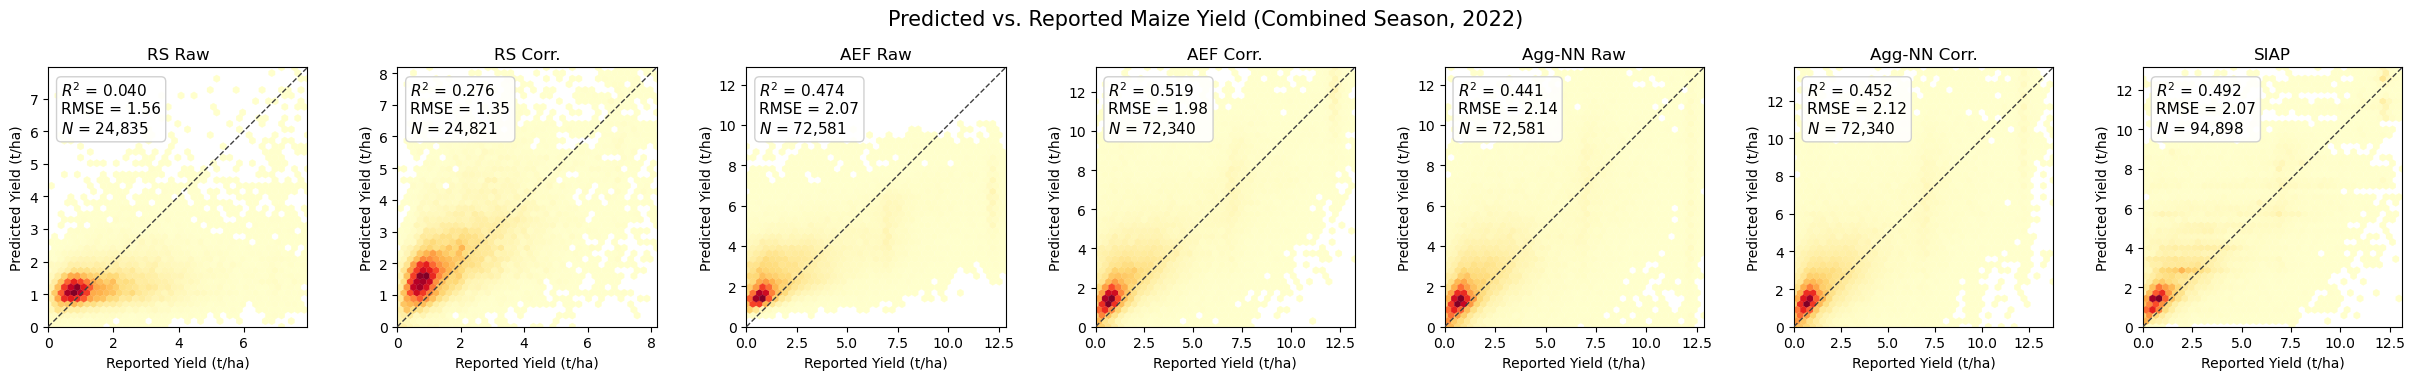

In [14]:
### ------------------------------------------------------------------ ###
### Scatter plots: Combined season — predicted vs INEGI census yield
### ------------------------------------------------------------------ ###

plot_models = [
    ('yield_pred_rs',            'RS Raw'),
    ('yield_pred_rs_corr_add',   'RS Corr.'),
    ('yield_pred_aef',           'AEF Raw'),
    ('yield_pred_aef_corr_add',  'AEF Corr.'),
    ('yield_pred_mlp',           'Agg-NN Raw'),
    ('yield_pred_mlp_corr_add',  'Agg-NN Corr.'),
    ('yield_siap',               'SIAP'),
]

### Filter to columns that exist
plot_models = [(pc, nm) for pc, nm in plot_models if pc in df.columns]

n_cols = len(plot_models)
fig, axes = plt.subplots(1, n_cols, figsize=(3.5 * n_cols, 3.5))
if n_cols == 1:
    axes = [axes]

for ax, (pred_col, model_name) in zip(axes, plot_models):
    hb = scatter_pred_vs_actual(ax, df['yield'], df[pred_col], title=model_name)

fig.suptitle("Predicted vs. Reported Maize Yield (Combined Season, 2022)",
             y=1.02, fontsize=base_font_size + 3)
fig.tight_layout()
fig.savefig(os.path.join(plot_dir, "accuracy_scatter_combined_2022.png"),
            bbox_inches='tight', dpi=200)
fig.savefig(os.path.join(plot_dir, "accuracy_scatter_combined_2022.pdf"),
            bbox_inches='tight')
plt.show()

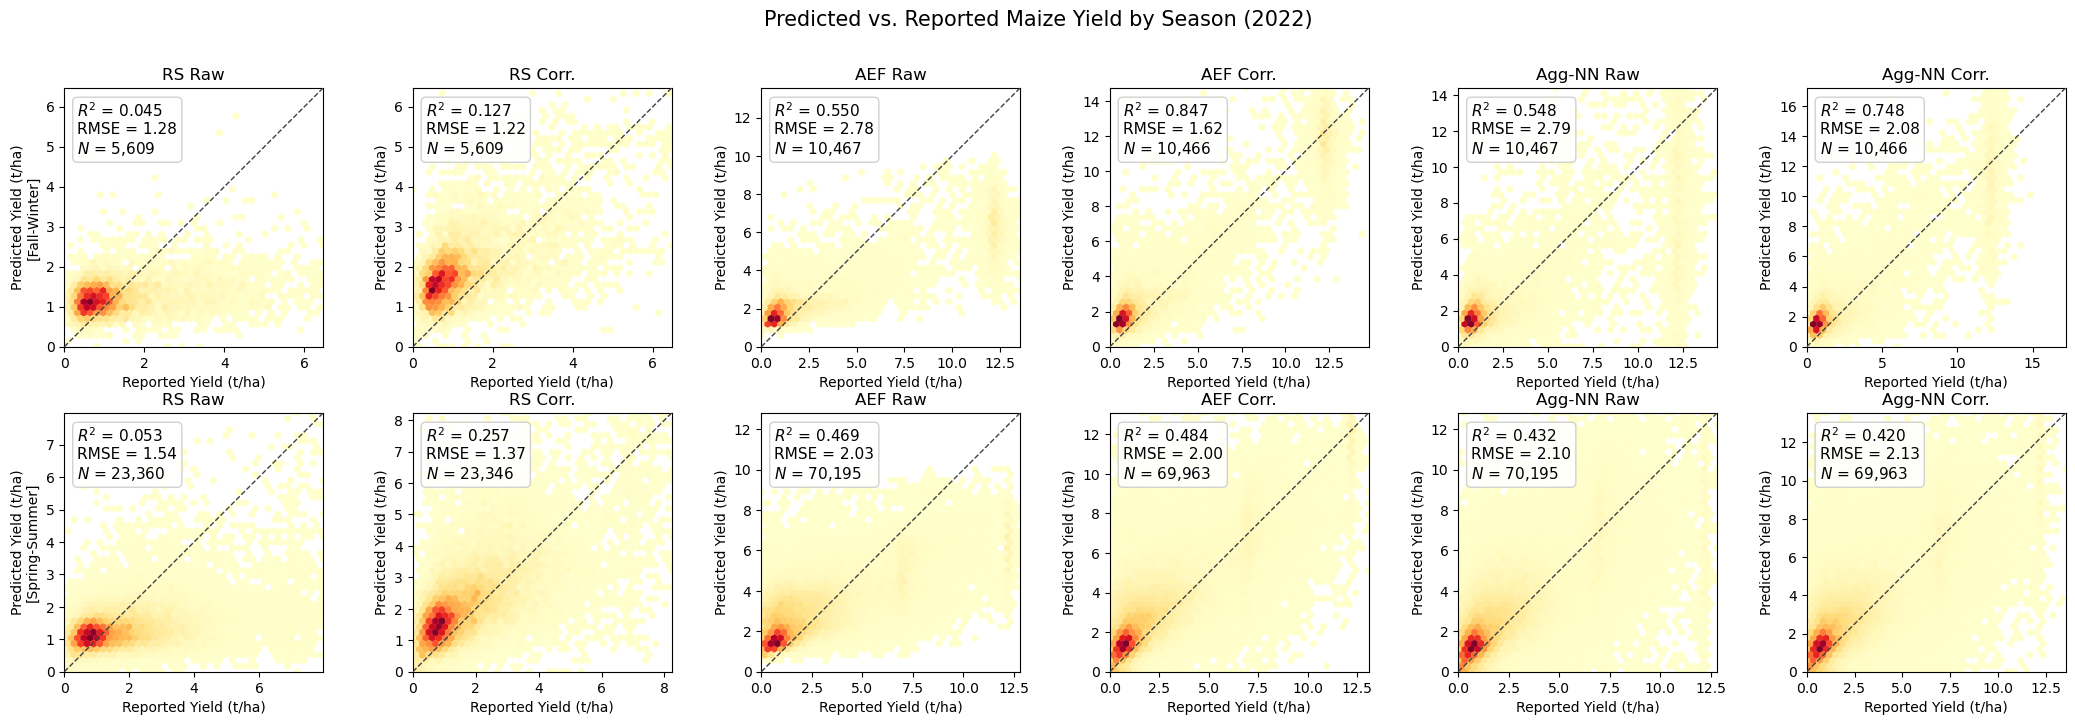

In [15]:
### ------------------------------------------------------------------ ###
### Scatter plots by season: Fall-Winter (O-I) and Spring-Summer (P-V)
### ------------------------------------------------------------------ ###

seasonal_models = [
    ('yield_pred_rs',           'RS Raw'),
    ('yield_pred_rs_corr_add',  'RS Corr.'),
    ('yield_pred_aef',          'AEF Raw'),
    ('yield_pred_aef_corr_add', 'AEF Corr.'),
    ('yield_pred_mlp',          'Agg-NN Raw'),
    ('yield_pred_mlp_corr_add', 'Agg-NN Corr.'),
]

### Filter to columns that exist
seasonal_models = [(pc, nm) for pc, nm in seasonal_models if pc in df.columns]

n_cols = len(seasonal_models)
fig, axes = plt.subplots(2, n_cols, figsize=(3.5 * n_cols, 7.0))

### Fall-Winter (O-I)
for ax, (pred_col, model_name) in zip(axes[0], seasonal_models):
    scatter_pred_vs_actual(ax, df['yield_oi'], df[pred_col],
                           title=f"{model_name}")
axes[0][0].set_ylabel("Predicted Yield (t/ha)\n[Fall-Winter]")

### Spring-Summer (P-V)
for ax, (pred_col, model_name) in zip(axes[1], seasonal_models):
    scatter_pred_vs_actual(ax, df['yield_pv'], df[pred_col],
                           title=f"{model_name}")
axes[1][0].set_ylabel("Predicted Yield (t/ha)\n[Spring-Summer]")

fig.suptitle("Predicted vs. Reported Maize Yield by Season (2022)",
             y=1.02, fontsize=base_font_size + 3)
fig.tight_layout()
fig.savefig(os.path.join(plot_dir, "accuracy_scatter_seasonal_2022.png"),
            bbox_inches='tight', dpi=200)
fig.savefig(os.path.join(plot_dir, "accuracy_scatter_seasonal_2022.pdf"),
            bbox_inches='tight')
plt.show()

#### Diagnostics

In [16]:
### ------------------------------------------------------------------ ###
### Diagnostic: municipality coverage and within-municipality variation
### ------------------------------------------------------------------ ###

### How many ADCs per municipality have predictions?
for pred_col, model_name in pred_models.items():
    sub   =  df[df[pred_col].notna() & df['yield'].notna()]
    n_mun =  sub['muncode'].nunique()
    n_adc =  len(sub)
    avg   =  sub.groupby('muncode').size().mean()
    med   =  sub.groupby('muncode').size().median()
    pct2  =  (sub.groupby('muncode').size() >= 2).mean() * 100
    print(f"{model_name:20s}: {n_adc:>6,} ADCs in {n_mun:>5,} muns "
          f"(avg {avg:.1f}, med {med:.0f} ADCs/mun, {pct2:.0f}% muns w/ ≥2 ADCs)")

RS Raw              : 24,835 ADCs in   604 muns (avg 41.1, med 28 ADCs/mun, 96% muns w/ ≥2 ADCs)
RS Corr. (Add.)     : 24,821 ADCs in   603 muns (avg 41.2, med 28 ADCs/mun, 96% muns w/ ≥2 ADCs)
AEF Raw             : 72,581 ADCs in 2,060 muns (avg 35.2, med 18 ADCs/mun, 90% muns w/ ≥2 ADCs)
AEF Corr. (Add.)    : 72,340 ADCs in 2,029 muns (avg 35.7, med 18 ADCs/mun, 90% muns w/ ≥2 ADCs)
Agg-NN Raw          : 72,581 ADCs in 2,060 muns (avg 35.2, med 18 ADCs/mun, 90% muns w/ ≥2 ADCs)
Agg-NN Corr. (Add.) : 72,340 ADCs in 2,029 muns (avg 35.7, med 18 ADCs/mun, 90% muns w/ ≥2 ADCs)
SIAP Mun. Avg.      : 94,898 ADCs in 2,039 muns (avg 46.5, med 23 ADCs/mun, 92% muns w/ ≥2 ADCs)
